# Fire2Air Darwin — Assessment 3
## 04 Model 3 Count Prediction and Explainability — AWS Notebook
**Member:** Navodya Piumanthi

## Cell 1 — Imports and optional modelling packages
Loads the modelling, explainability and AWS dependencies. XGBoost and SHAP remain optional so the notebook can still run if either package is unavailable.

In [2]:
from pathlib import Path
import json
import joblib
import shutil
import tempfile

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import PoissonRegressor, TweedieRegressor
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    mean_poisson_deviance,
)

import boto3

try:
    from xgboost import XGBRegressor
    HAS_XGBOOST = True
except Exception as exc:
    HAS_XGBOOST = False
    print("XGBoost unavailable:", exc)

try:
    import shap
    HAS_SHAP = True
except Exception as exc:
    HAS_SHAP = False
    print("SHAP unavailable:", exc)

print("XGBoost available:", HAS_XGBOOST)
print("SHAP available:", HAS_SHAP)


XGBoost available: True
SHAP available: True


In [18]:
%pip install "botocore[crt]"

  Using cached awscrt-0.36.0-cp313-abi3-win_amd64.whl.metadata (11 kB)
Using cached awscrt-0.36.0-cp313-abi3-win_amd64.whl (4.3 MB)
Note: you may need to restart the kernel to use updated packages.


In [1]:
import awscrt
import botocore

print("AWS CRT installed successfully")
print("Botocore version:", botocore.__version__)

AWS CRT installed successfully
Botocore version: 1.43.93


## Cell 2 — Shared AWS S3 configuration and helper functions
Uses the same bucket/prefix structure as the other Fire2Air AWS scripts and adds reusable download, upload and listing helpers.

In [3]:
AWS_REGION = "ap-southeast-2"
BUCKET = "fire2air-darwin-dan5-646468992009-ap-southeast-2-an"


NTEPA_RAW = f"s3://{BUCKET}/raw/ntepa/"
FIRMS_RAW = f"s3://{BUCKET}/raw/firms/"
NTEPA_DAILY = f"s3://{BUCKET}/processed/ntepa_daily/"
FIRMS_DAILY = f"s3://{BUCKET}/processed/firms_daily/"
MODEL_READY = f"s3://{BUCKET}/processed/model_ready/"

MODEL1_DIR = f"s3://{BUCKET}/models/model1/"
MODEL2_DIR = f"s3://{BUCKET}/models/model2/"
MODEL3_DIR = f"s3://{BUCKET}/models/model3/"

MODEL1_OUTPUT = f"s3://{BUCKET}/outputs/model1/"
MODEL2_OUTPUT = f"s3://{BUCKET}/outputs/model2/"
MODEL3_OUTPUT = f"s3://{BUCKET}/outputs/model3/"

VIS_OUTPUT = f"s3://{BUCKET}/outputs/visualisation/"
DASHBOARD_DIR = f"s3://{BUCKET}/dashboard/"
DOCUMENTATION_DIR = f"s3://{BUCKET}/documentation/"
ATHENA_RESULTS = f"s3://{BUCKET}/athena-results/"

session = boto3.Session(
    profile_name="fire2air",
    region_name=AWS_REGION,
)

s3 = session.client("s3")

# Cross-platform temporary workspace: works on Windows, macOS and Linux.
LOCAL_ROOT = Path(tempfile.gettempdir()) / "fire2air_a3"
LOCAL_ROOT.mkdir(parents=True, exist_ok=True)

def _prefix(uri):
    return uri.replace(f"s3://{BUCKET}/", "", 1)

def download_prefix(uri, local_dir, flatten=False):
    local_dir = Path(local_dir)
    local_dir.mkdir(parents=True, exist_ok=True)
    prefix = _prefix(uri)
    paginator = s3.get_paginator("list_objects_v2")
    downloaded = []

    for page in paginator.paginate(Bucket=BUCKET, Prefix=prefix):
        for obj in page.get("Contents", []):
            key = obj["Key"]
            if key.endswith("/"):
                continue

            rel = Path(key[len(prefix):].lstrip("/"))
            dest = local_dir / (rel.name if flatten else rel)
            dest.parent.mkdir(parents=True, exist_ok=True)

            s3.download_file(BUCKET, key, str(dest))
            downloaded.append(dest)

    return downloaded

def upload_file(local_path, uri, object_name=None):
    local_path = Path(local_path)
    prefix = _prefix(uri).rstrip("/")
    key = f"{prefix}/{object_name or local_path.name}"
    s3.upload_file(str(local_path), BUCKET, key)
    print(f"Uploaded: s3://{BUCKET}/{key}")
    return key

def upload_tree(local_dir, uri):
    local_dir = Path(local_dir)
    if not local_dir.exists():
        return []

    prefix = _prefix(uri).rstrip("/")
    uploaded = []

    for p in local_dir.rglob("*"):
        if p.is_file():
            rel = p.relative_to(local_dir).as_posix()
            key = f"{prefix}/{rel}"
            s3.upload_file(str(p), BUCKET, key)
            uploaded.append(key)

    print(f"Uploaded {len(uploaded)} file(s): {local_dir} -> {uri}")
    return uploaded

def list_prefix(uri):
    prefix = _prefix(uri)
    paginator = s3.get_paginator("list_objects_v2")
    rows = []

    for page in paginator.paginate(Bucket=BUCKET, Prefix=prefix):
        for obj in page.get("Contents", []):
            if obj["Key"].endswith("/"):
                continue
            rows.append({
                "Key": obj["Key"],
                "Size_Bytes": obj["Size"],
                "Last_Modified": obj["LastModified"],
            })

    return pd.DataFrame(rows)


## Cell 3 — AWS preflight, download shared model-ready data and initialise workspace
Checks S3 access, verifies the required shared checkpoint/manifest exist, downloads them, creates the local output folders, and loads the Model 3 target and feature manifest.

In [4]:
RANDOM_STATE = 42
BOOTSTRAP_REPEATS = 300

project_folder = LOCAL_ROOT / "model3_workspace"
if project_folder.exists():
    shutil.rmtree(project_folder)
project_folder.mkdir(parents=True, exist_ok=True)

# Confirm the project bucket is accessible.
s3.head_bucket(Bucket=BUCKET)

model_ready_objects = list_prefix(MODEL_READY)
if model_ready_objects.empty:
    raise FileNotFoundError(f"No objects found under {MODEL_READY}")

required_files = {
    "Fire2Air_model_ready_checkpoint_A3.csv",
    "Fire2Air_feature_manifest_A3.json",
}
available_names = {Path(key).name for key in model_ready_objects["Key"]}
missing_required = required_files.difference(available_names)

if missing_required:
    raise FileNotFoundError(
        f"Required Model 3 input file(s) missing from {MODEL_READY}: "
        f"{sorted(missing_required)}"
    )

print("Model-ready S3 objects:")
display(model_ready_objects)

downloaded_files = download_prefix(
    MODEL_READY,
    project_folder,
    flatten=True,
)
print(f"Downloaded {len(downloaded_files)} file(s) to:", project_folder)

output_root = project_folder / "outputs_prt661_a3"
table_dir = output_root / "tables"
figure_dir = output_root / "figures"
model_dir = output_root / "models"

for folder in [table_dir, figure_dir, model_dir]:
    folder.mkdir(parents=True, exist_ok=True)

data_path = project_folder / "Fire2Air_model_ready_checkpoint_A3.csv"
manifest_path = project_folder / "Fire2Air_feature_manifest_A3.json"

integrated_daily = pd.read_csv(
    data_path,
    parse_dates=["date", "target_date"],
)

with open(manifest_path, "r", encoding="utf-8") as f:
    manifest = json.load(f)

model_features = manifest["features"]
feature_groups = manifest["feature_groups"]
duration_target = manifest["targets"]["count"]

print("AWS staging folder:", project_folder)
print("Dataset shape:", integrated_daily.shape)
print("Predictor count:", len(model_features))
print("Count target:", duration_target)


Model-ready S3 objects:


,Key,Size_Bytes,Last_Modified
0,processed/model_ready/Fire2Air_ablation_featur...,11203,2026-10-02 17:50:39+00:00
1,processed/model_ready/Fire2Air_feature_manifes...,15765,2026-10-02 17:50:39+00:00
2,processed/model_ready/Fire2Air_integrated_dail...,8164937,2026-10-02 17:50:35+00:00
3,processed/model_ready/Fire2Air_model_ready_che...,8116877,2026-10-02 17:50:37+00:00


Downloaded 4 file(s) to: C:\Users\navod\AppData\Local\Temp\fire2air_a3\model3_workspace
AWS staging folder: C:\Users\navod\AppData\Local\Temp\fire2air_a3\model3_workspace
Dataset shape: (7530, 120)
Predictor count: 93
Count target: target_hours_ge_25_next_day


## Cell 4 — Chronological split and target validation
Creates the leakage-safe training/validation/test periods and confirms the Model 3 target is physically valid from 0 to 24 hours.


In [5]:
duration_data = integrated_daily.dropna(
    subset=[duration_target, "target_date"]
).copy()

duration_data["target_year"] = duration_data["target_date"].dt.year

train_duration = duration_data[
    duration_data["target_year"] <= 2022
].copy()

validation_duration = duration_data[
    duration_data["target_year"] == 2023
].copy()

test_duration = duration_data[
    duration_data["target_year"] == 2024
].copy()

if min(
    len(train_duration),
    len(validation_duration),
    len(test_duration),
) == 0:
    raise ValueError(
        f"Insufficient chronological data: "
        f"train={len(train_duration)}, "
        f"validation={len(validation_duration)}, "
        f"test={len(test_duration)}"
    )

assert (
    train_duration["target_date"].max()
    < validation_duration["target_date"].min()
)

assert (
    validation_duration["target_date"].max()
    < test_duration["target_date"].min()
)

assert duration_data[duration_target].between(0, 24).all()

X_train = train_duration[model_features]
y_train = train_duration[duration_target]

X_validation = validation_duration[model_features]
y_validation = validation_duration[duration_target]

X_test = test_duration[model_features]
y_test = test_duration[duration_target]

print(
    "Split sizes:",
    {
        "train_2018_2022": len(train_duration),
        "validation_2023": len(validation_duration),
        "test_2024": len(test_duration),
    },
)
print(
    "Target range:",
    float(duration_data[duration_target].min()),
    "to",
    float(duration_data[duration_target].max()),
)


Split sizes: {'train_2018_2022': 2415, 'validation_2023': 661, 'test_2024': 645}
Target range: 0.0 to 24.0


## Cell 5 — Preprocessing, prediction bounds and count metrics

Defines reusable preprocessing and the Model 3 evaluation metrics, including MAE, RMSE, R² and mean Poisson deviance.

In [6]:
def onehot():
    try:
        return OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False,
        )
    except TypeError:
        return OneHotEncoder(
            handle_unknown="ignore",
            sparse=False,
        )


def build_preprocessor(features, scale_numeric=False):
    categorical = [f for f in features if f == "station"]
    numeric = [f for f in features if f not in categorical]

    transformers = []

    if categorical:
        transformers.append((
            "categorical",
            Pipeline([
                (
                    "imputer",
                    SimpleImputer(strategy="most_frequent"),
                ),
                ("onehot", onehot()),
            ]),
            categorical,
        ))

    numeric_steps = [
        ("imputer", SimpleImputer(strategy="median"))
    ]

    if scale_numeric:
        numeric_steps.append(
            ("scaler", StandardScaler())
        )

    if numeric:
        transformers.append((
            "numeric",
            Pipeline(numeric_steps),
            numeric,
        ))

    return ColumnTransformer(transformers)


def bounded(predictions):
    return np.clip(
        np.asarray(predictions, dtype=float),
        0,
        24,
    )


def count_metrics(y_true, predictions):
    y = np.asarray(y_true, dtype=float)
    pred = bounded(predictions)

    return {
        "MAE": mean_absolute_error(y, pred),
        "RMSE": float(
            np.sqrt(mean_squared_error(y, pred))
        ),
        "R2": (
            r2_score(y, pred)
            if len(y) >= 2
            else np.nan
        ),
        "Mean_Poisson_Deviance": mean_poisson_deviance(
            y,
            np.clip(pred, 1e-6, None),
        ),
        "Prediction_Min": float(pred.min()),
        "Prediction_Max": float(pred.max()),
    }


def duration_strata_metrics(y_true, predictions):
    y = np.asarray(y_true, dtype=float)
    pred = bounded(predictions)

    strata = [
        ("Zero hours", y == 0),
        ("Low duration 1-5 h", (y >= 1) & (y <= 5)),
        ("Medium duration 6-12 h", (y >= 6) & (y <= 12)),
        ("Long duration 13-24 h", y >= 13),
    ]

    rows = []

    for label, mask in strata:
        if mask.sum() > 0:
            rows.append({
                "Stratum": label,
                "Rows": int(mask.sum()),
                "MAE": mean_absolute_error(
                    y[mask],
                    pred[mask],
                ),
                "RMSE": float(
                    np.sqrt(
                        mean_squared_error(
                            y[mask],
                            pred[mask],
                        )
                    )
                ),
                "Bias_PredMinusObs": float(
                    np.mean(pred[mask] - y[mask])
                ),
            })

    return rows


## Cell 6 — Exploratory two-stage Hurdle Random Forest

Implements the Assessment 3 two-stage benchmark: first estimate whether any elevated hour occurs, then estimate positive duration.


In [7]:
class HurdleRandomForest(
    BaseEstimator,
    RegressorMixin,
):
    """Exploratory two-stage count model.

    Stage 1 predicts whether any elevated hour occurs.
    Stage 2 predicts duration on positive-duration days.
    Expected duration = P(any event) * predicted positive hours.
    """

    def __init__(
        self,
        features,
        n_estimators=300,
        max_depth=None,
        min_samples_leaf=2,
        random_state=42,
    ):
        self.features = features
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.min_samples_leaf = min_samples_leaf
        self.random_state = random_state

    def fit(self, X, y):
        self.preprocessor_ = build_preprocessor(
            self.features,
            scale_numeric=False,
        )

        Xt = self.preprocessor_.fit_transform(
            X[self.features]
        )

        y_arr = np.asarray(y, dtype=float)

        self.classifier_ = RandomForestClassifier(
            n_estimators=self.n_estimators,
            max_depth=self.max_depth,
            min_samples_leaf=self.min_samples_leaf,
            class_weight="balanced",
            random_state=self.random_state,
            n_jobs=-1,
        )

        self.classifier_.fit(
            Xt,
            (y_arr > 0).astype(int),
        )

        positive = y_arr > 0

        self.regressor_ = RandomForestRegressor(
            n_estimators=self.n_estimators,
            max_depth=self.max_depth,
            min_samples_leaf=self.min_samples_leaf,
            random_state=self.random_state,
            n_jobs=-1,
        )

        if positive.sum() > 0:
            self.regressor_.fit(
                Xt[positive],
                y_arr[positive],
            )
            self.positive_mean_ = float(
                np.mean(y_arr[positive])
            )
        else:
            self.positive_mean_ = 1.0

        return self

    def predict(self, X):
        Xt = self.preprocessor_.transform(
            X[self.features]
        )

        probabilities = self.classifier_.predict_proba(Xt)

        if probabilities.shape[1] == 1:
            only_class = int(self.classifier_.classes_[0])
            p_any = np.ones(len(X)) if only_class == 1 else np.zeros(len(X))
        else:
            positive_class_index = int(
                np.where(self.classifier_.classes_ == 1)[0][0]
            )
            p_any = probabilities[:, positive_class_index]

        try:
            positive_hours = self.regressor_.predict(Xt)
        except Exception:
            positive_hours = np.repeat(
                self.positive_mean_,
                len(X),
            )

        return bounded(
            p_any
            * np.clip(
                positive_hours,
                0,
                24,
            )
        )


## Cell 7 — Reusable Model 3 count-model builder

Builds each candidate model with the correct preprocessing and count-specific objective.

In [8]:
def build_count_model(
    model_name,
    params,
    features,
):
    if model_name == "Poisson Regression":
        return Pipeline([
            (
                "preprocessor",
                build_preprocessor(
                    features,
                    scale_numeric=True,
                ),
            ),
            (
                "model",
                PoissonRegressor(
                    alpha=params["alpha"],
                    max_iter=1000,
                ),
            ),
        ])

    if model_name == "Tweedie Regression":
        return Pipeline([
            (
                "preprocessor",
                build_preprocessor(
                    features,
                    scale_numeric=True,
                ),
            ),
            (
                "model",
                TweedieRegressor(
                    power=1.5,
                    alpha=params["alpha"],
                    link="log",
                    max_iter=1000,
                ),
            ),
        ])

    if model_name == "Random Forest":
        return Pipeline([
            (
                "preprocessor",
                build_preprocessor(
                    features,
                    scale_numeric=False,
                ),
            ),
            (
                "model",
                RandomForestRegressor(
                    n_estimators=300,
                    max_depth=params["max_depth"],
                    min_samples_leaf=params[
                        "min_samples_leaf"
                    ],
                    random_state=RANDOM_STATE,
                    n_jobs=-1,
                ),
            ),
        ])

    if model_name == "XGBoost Poisson":
        if not HAS_XGBOOST:
            raise RuntimeError(
                "XGBoost is unavailable."
            )

        return Pipeline([
            (
                "preprocessor",
                build_preprocessor(
                    features,
                    scale_numeric=False,
                ),
            ),
            (
                "model",
                XGBRegressor(
                    n_estimators=params[
                        "n_estimators"
                    ],
                    learning_rate=params[
                        "learning_rate"
                    ],
                    max_depth=params["max_depth"],
                    objective="count:poisson",
                    eval_metric="poisson-nloglik",
                    random_state=RANDOM_STATE,
                    n_jobs=-1,
                ),
            ),
        ])

    if model_name == "Hurdle Random Forest":
        return HurdleRandomForest(
            features=features,
            n_estimators=300,
            max_depth=params["max_depth"],
            min_samples_leaf=params[
                "min_samples_leaf"
            ],
            random_state=RANDOM_STATE,
        )

    raise ValueError(
        f"Unknown count model: {model_name}"
    )


## Cell 8 — Candidate model configurations

Defines the Model 3 candidate grid without fitting anything yet. Keeping this separate makes the dependency order explicit.

In [9]:
candidate_specs = [
    (
        "Poisson Regression",
        {"alpha": 0.1},
        "alpha=0.1",
    ),
    (
        "Poisson Regression",
        {"alpha": 1.0},
        "alpha=1.0",
    ),
    (
        "Tweedie Regression",
        {"alpha": 0.1},
        "power=1.5;alpha=0.1",
    ),
    (
        "Tweedie Regression",
        {"alpha": 1.0},
        "power=1.5;alpha=1.0",
    ),
]

for max_depth, min_samples_leaf in [
    (None, 1),
    (None, 4),
    (10, 4),
    (15, 4),
]:
    candidate_specs.append((
        "Random Forest",
        {
            "max_depth": max_depth,
            "min_samples_leaf": min_samples_leaf,
        },
        (
            f"max_depth={max_depth};"
            f"min_samples_leaf={min_samples_leaf}"
        ),
    ))

candidate_specs.append((
    "Hurdle Random Forest",
    {
        "max_depth": 10,
        "min_samples_leaf": 4,
    },
    "two-stage:any-event+positive-duration",
))

if HAS_XGBOOST:
    for (
        n_estimators,
        learning_rate,
        max_depth,
    ) in [
        (100, 0.05, 2),
        (200, 0.05, 2),
        (300, 0.05, 2),
        (200, 0.05, 3),
    ]:
        candidate_specs.append((
            "XGBoost Poisson",
            {
                "n_estimators": n_estimators,
                "learning_rate": learning_rate,
                "max_depth": max_depth,
            },
            (
                f"n_estimators={n_estimators};"
                f"learning_rate={learning_rate};"
                f"max_depth={max_depth}"
            ),
        ))

print("Candidate configurations:", len(candidate_specs))
for model_name, _, config_id in candidate_specs:
    print(f"- {model_name}: {config_id}")


Candidate configurations: 13
- Poisson Regression: alpha=0.1
- Poisson Regression: alpha=1.0
- Tweedie Regression: power=1.5;alpha=0.1
- Tweedie Regression: power=1.5;alpha=1.0
- Random Forest: max_depth=None;min_samples_leaf=1
- Random Forest: max_depth=None;min_samples_leaf=4
- Random Forest: max_depth=10;min_samples_leaf=4
- Random Forest: max_depth=15;min_samples_leaf=4
- Hurdle Random Forest: two-stage:any-event+positive-duration
- XGBoost Poisson: n_estimators=100;learning_rate=0.05;max_depth=2
- XGBoost Poisson: n_estimators=200;learning_rate=0.05;max_depth=2
- XGBoost Poisson: n_estimators=300;learning_rate=0.05;max_depth=2
- XGBoost Poisson: n_estimators=200;learning_rate=0.05;max_depth=3


## Cell 9 — 2023 validation tuning and model selection

Fits every candidate on the training period, evaluates 2023 validation performance, saves the comparison table, and selects the best configuration by MAE with RMSE and Poisson deviance as tie-breakers.

In [10]:
validation_rows = []
model_templates = {}
params_lookup = {}

for (
    model_name,
    params,
    config_id,
) in candidate_specs:

    model = build_count_model(
        model_name,
        params,
        model_features,
    )

    model.fit(
        X_train,
        y_train,
    )

    raw_pred = model.predict(
        X_validation
    )

    validation_rows.append({
        "Model": model_name,
        "Config": config_id,
        "Raw_Negative_Predictions": int(
            (
                np.asarray(raw_pred) < 0
            ).sum()
        ),
        **count_metrics(
            y_validation,
            raw_pred,
        ),
    })

    model_templates[
        (model_name, config_id)
    ] = model

    params_lookup[
        (model_name, config_id)
    ] = params

validation_results = (
    pd.DataFrame(validation_rows)
    .sort_values([
        "MAE",
        "RMSE",
        "Mean_Poisson_Deviance",
    ])
    .reset_index(drop=True)
)

validation_results.to_csv(
    table_dir
    / "a3_model3_count_validation_results.csv",
    index=False,
)

print(
    "\n2023 count validation results:"
)
print(
    validation_results
    .round(4)
    .to_string(index=False)
)

selected = validation_results.iloc[0]

best_model_name = selected["Model"]
best_config_id = selected["Config"]

selected_params = params_lookup[
    (best_model_name, best_config_id)
]

selected_template = model_templates[
    (best_model_name, best_config_id)
]

print(
    "\nSelected count model by validation MAE:",
    best_model_name,
)
print(
    "Configuration:",
    best_config_id,
)



2023 count validation results:
               Model                                          Config  Raw_Negative_Predictions    MAE   RMSE     R2  Mean_Poisson_Deviance  Prediction_Min  Prediction_Max
  Poisson Regression                                       alpha=0.1                         0 2.2377 3.6821 0.5821                 3.2100          0.0125         24.0000
  Tweedie Regression                             power=1.5;alpha=0.1                         0 2.2523 3.8112 0.5523                 3.2461          0.0078         24.0000
  Poisson Regression                                       alpha=1.0                         0 2.3820 3.8604 0.5406                 3.2758          0.0728         24.0000
       Random Forest                 max_depth=10;min_samples_leaf=4                         0 2.4298 4.0159 0.5029                 3.3071          0.0272         12.4798
       Random Forest                 max_depth=15;min_samples_leaf=4                         0 2.4367 4.0216 0.50

## Cell 10 — A–F ablation study

Keeps the selected model family/configuration fixed while adding the cumulative Assessment 3 feature groups.


In [12]:
ablation_rows = []

for (
    stage,
    stage_features,
) in feature_groups.items():

    stage_features = [
        f
        for f in stage_features
        if f in duration_data.columns
    ]

    model = build_count_model(
        best_model_name,
        selected_params,
        stage_features,
    )

    model.fit(
        train_duration[stage_features],
        y_train,
    )

    pred = model.predict(
        validation_duration[stage_features]
    )

    ablation_rows.append({
        "Stage": stage,
        "Feature_Count": len(stage_features),
        **count_metrics(
            y_validation,
            pred,
        ),
    })

ablation_results = pd.DataFrame(
    ablation_rows
)

ablation_results.to_csv(
    table_dir
    / "a3_model3_ablation_results.csv",
    index=False,
)

print(
    ablation_results
    .round(4)
    .to_string(index=False)
)


           Stage  Feature_Count    MAE   RMSE     R2  Mean_Poisson_Deviance  Prediction_Min  Prediction_Max
   A_air_weather             54 2.2621 3.7159 0.5744                 3.2909          0.0052            24.0
    B_basic_fire             63 2.2884 3.7666 0.5627                 3.3047          0.0101            24.0
C_fire_intensity             72 2.2482 3.7228 0.5728                 3.2537          0.0103            24.0
      D_fire_age             84 2.2506 3.7223 0.5729                 3.2567          0.0111            24.0
E_wind_alignment             91 2.2416 3.6925 0.5797                 3.2031          0.0122            24.0
      F_full_FSI             93 2.2377 3.6821 0.5821                 3.2100          0.0125            24.0


## Cell 11 — Final 2024 benchmark and duration-strata diagnostics

Retrains the selected configuration on 2018–2023 development data, evaluates 2024, creates duration-strata diagnostics, and saves observed-vs-predicted evidence.


Final 2024 count performance:
             Model    Config  Raw_Negative_Predictions    MAE   RMSE     R2  Mean_Poisson_Deviance  Prediction_Min  Prediction_Max
Poisson Regression alpha=0.1                         0 1.3058 2.1642 0.4575                 1.8845          0.0153         13.5244


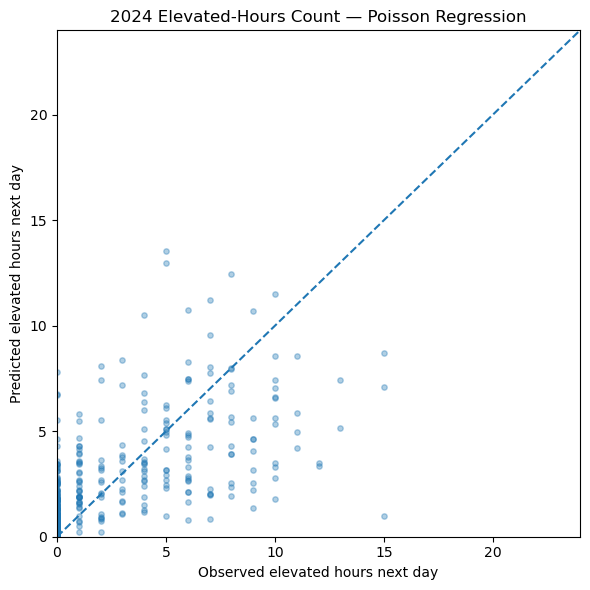

,Stratum,Rows,MAE,RMSE,Bias_PredMinusObs
0,Zero hours,457,0.739568,1.214303,0.739568
1,Low duration 1-5 h,109,1.747306,2.379918,0.737125
2,Medium duration 6-12 h,74,3.677797,4.254014,-2.931174
3,Long duration 13-24 h,5,8.322551,8.838321,-8.322551


In [13]:
development_duration = pd.concat(
    [
        train_duration,
        validation_duration,
    ],
    ignore_index=True,
)

X_development = development_duration[
    model_features
]

y_development = development_duration[
    duration_target
]

# Rebuild rather than clone custom hurdle models
# to avoid estimator-state ambiguity.
final_count_model = build_count_model(
    best_model_name,
    selected_params,
    model_features,
)

final_count_model.fit(
    X_development,
    y_development,
)

raw_test_predictions = (
    final_count_model.predict(X_test)
)

test_predictions = bounded(
    raw_test_predictions
)

final_metrics = {
    "Model": best_model_name,
    "Config": best_config_id,
    "Raw_Negative_Predictions": int(
        (
            np.asarray(
                raw_test_predictions
            ) < 0
        ).sum()
    ),
    **count_metrics(
        y_test,
        raw_test_predictions,
    ),
}

final_metrics_df = pd.DataFrame(
    [final_metrics]
)

final_metrics_df.to_csv(
    table_dir
    / "a3_model3_final_2024_metrics.csv",
    index=False,
)

print(
    "\nFinal 2024 count performance:"
)
print(
    final_metrics_df
    .round(4)
    .to_string(index=False)
)

strata_results = pd.DataFrame(
    duration_strata_metrics(
        y_test,
        test_predictions,
    )
)

strata_results.to_csv(
    table_dir
    / "a3_model3_2024_duration_strata.csv",
    index=False,
)

fig, ax = plt.subplots(
    figsize=(6, 6)
)

ax.scatter(
    y_test,
    test_predictions,
    alpha=0.35,
    s=15,
)

ax.plot(
    [0, 24],
    [0, 24],
    linestyle="--",
)

ax.set_xlim(0, 24)
ax.set_ylim(0, 24)

ax.set_xlabel(
    "Observed elevated hours next day"
)
ax.set_ylabel(
    "Predicted elevated hours next day"
)

ax.set_title(
    f"2024 Elevated-Hours Count — "
    f"{best_model_name}"
)

fig.tight_layout()

fig.savefig(
    figure_dir
    / "a3_model3_2024_observed_vs_predicted.png",
    dpi=180,
    bbox_inches="tight",
)

plt.show()
plt.close(fig)

display(strata_results)
